# Crimen, Desarrollo Digital y Crecimiento Económico en México
**DataFrames para análisis de regresión y clasificación · Panel estatal 2015–2024**

- **DF1** — Panel estado × año (2015–2022): incidencia delictiva + crecimiento del PIB
- **DF2** — Panel IDDE × crimen (2022–2024): desarrollo digital + crimen por estado
- **DF3** — Snapshot 2022: perfil integral por estado (crimen + IDDE + PIB)

In [2]:
import sqlite3
import pandas as pd
import numpy as np

DB_PATH = 'HuaweiProject.db'

In [3]:
BIEN_MAP = {
    'Feminicidio':'Vida','Homicidio doloso':'Vida','Homicidio culposo':'Vida',
    'Lesiones dolosas':'Vida','Lesiones culposas':'Vida','Aborto':'Vida',
    'Secuestro':'Libertad','Trata de personas':'Libertad','Rapto':'Libertad',
    'Otros delitos que atentan contra la libertad personal':'Libertad',
    'Violación simple':'Sexual','Violación equiparada':'Sexual',
    'Abuso sexual':'Sexual','Acoso sexual':'Sexual','Hostigamiento sexual':'Sexual',
    'Otros delitos que atentan contra la libertad y la seguridad sexual':'Sexual',
    'Violencia familiar':'Familia',
    'Violencia de género en todas sus modalidades distinta a la violencia familiar':'Familia',
    'Incesto':'Familia','Otros delitos contra la familia':'Familia',
    'Narcomenudeo':'Sociedad','Corrupción de menores':'Sociedad',
    'Tráfico de menores':'Sociedad','Lenocinio':'Sociedad',
    'Otros delitos contra la sociedad':'Sociedad',
    'Delitos ambientales':'Estado',
}
ROBOS = [
    'Robo de vehículo automotor','Robo a casa habitación','Robo a negocio',
    'Robo a transeúnte en vía pública con violencia','Robo a transeúnte en vía pública sin violencia',
    'Robo en transporte público colectivo','Robo a bordo de metro','Robo a institución bancaria',
    'Robo de autopartes','Robo de maquinaria','Robo de ganado','Robo de madera','Robo en carretera',
    'Robo a transportista','Robo a repartidor','Robo a bordo de microbús','Robo a bordo de taxi',
    'Robo a bordo de tren','Otros robos','Fraude','Extorsión','Abigeato','Despojo','Daño a la propiedad',
]
for r in ROBOS:
    BIEN_MAP[r] = 'Patrimonio'

POBLACION = {
    'Aguascalientes':       {2015:1312544, 2020:1434635, 2025:1563053},
    'Baja California':      {2015:3315766, 2020:3769020, 2025:4192534},
    'Baja California Sur':  {2015:712029,  2020:798447,  2025:897487},
    'Campeche':             {2015:899931,  2020:928363,  2025:975528},
    'Chiapas':              {2015:5217908, 2020:5543828, 2025:5816003},
    'Chihuahua':            {2015:3556574, 2020:3741869, 2025:3907760},
    'Ciudad de México':     {2015:8918653, 2020:9209944, 2025:9433137},
    'Coahuila de Zaragoza': {2015:2954915, 2020:3146771, 2025:3352283},
    'Colima':               {2015:711235,  2020:731391,  2025:754803},
    'Durango':              {2015:1754754, 2020:1832650, 2025:1906808},
    'Guanajuato':           {2015:5853677, 2020:6166934, 2025:6478042},
    'Guerrero':             {2015:3388768, 2020:3540685, 2025:3664869},
    'Hidalgo':              {2015:2858359, 2020:3082841, 2025:3302025},
    'Jalisco':              {2015:7844830, 2020:8348151, 2025:8848192},
    'México':               {2015:16187608,2020:16992418,2025:17694226},
    'Michoacán de Ocampo':  {2015:4584471, 2020:4748846, 2025:4898892},
    'Morelos':              {2015:1903811, 2020:1971520, 2025:2041576},
    'Nayarit':              {2015:1181050, 2020:1235456, 2025:1291112},
    'Nuevo León':           {2015:5119504, 2020:5784442, 2025:6373232},
    'Oaxaca':               {2015:3967889, 2020:4132148, 2025:4291270},
    'Puebla':               {2015:6168883, 2020:6583278, 2025:7011748},
    'Querétaro':            {2015:2038372, 2020:2368467, 2025:2689988},
    'Quintana Roo':         {2015:1501562, 2020:1857985, 2025:2184143},
    'San Luis Potosí':      {2015:2717820, 2020:2822255, 2025:2936889},
    'Sinaloa':              {2015:2966321, 2020:3026981, 2025:3083898},
    'Sonora':               {2015:2850330, 2020:2944840, 2025:3046739},
    'Tabasco':              {2015:2395272, 2020:2402598, 2025:2433765},
    'Tamaulipas':           {2015:3441698, 2020:3527735, 2025:3615694},
    'Tlaxcala':             {2015:1272847, 2020:1342977, 2025:1407844},
    'Veracruz de Ignacio de la Llave': {2015:8112505,2020:8062579,2025:8028879},
    'Yucatán':              {2015:2097175, 2020:2320898, 2025:2511049},
    'Zacatecas':            {2015:1579209, 2020:1622138, 2025:1663029},
}

def get_pob(estado, anio):
    data = POBLACION.get(estado)
    if not data: return np.nan
    years = sorted(data)
    if anio <= years[0]:  return data[years[0]]
    if anio >= years[-1]: return data[years[-1]]
    for i in range(len(years)-1):
        y0, y1 = years[i], years[i+1]
        if y0 <= anio <= y1:
            return data[y0] + (anio-y0)/(y1-y0) * (data[y1]-data[y0])

print('BIEN_MAP:', len(BIEN_MAP), 'subtipos')

BIEN_MAP: 50 subtipos


## 1. Carga del TXT de PIB → SQLite

In [4]:
df_raw = pd.read_csv('pib_limpio.txt', index_col=0, encoding='utf-8')

mask_anual = df_raw['Trimestre'].str.strip().str.startswith('Anual')
df_pib = df_raw[mask_anual][['Estado','Año','variacion_pib']].copy()
df_pib.columns = ['estado', 'anio', 'variacion_pib']
df_pib['anio'] = df_pib['anio'].astype(int)
df_pib['variacion_pib'] = df_pib['variacion_pib'].astype(float)
df_pib = df_pib.reset_index(drop=True)

with sqlite3.connect(DB_PATH) as conn:
    df_pib.to_sql('pib_estatal', conn, if_exists='replace', index=False)

print(f'Filas cargadas: {len(df_pib)}')
print(f'Años disponibles: {sorted(df_pib.anio.unique())}')
print(f'Estados únicos: {df_pib.estado.nunique()}')
df_pib.describe()

Filas cargadas: 256
Años disponibles: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022]
Estados únicos: 32


,anio,variacion_pib
count,256.000000,256.000000
mean,2018.500000,1.168743
std,2.295776,5.245081
min,2015.000000,-23.433094
25%,2016.750000,-0.587425
50%,2018.500000,2.353930
75%,2020.250000,4.077466
max,2022.000000,16.730372


## 2. DataFrame 1 — Panel Estado × Año (2015–2022)

**n ≈ 256 obs** (32 estados × 8 años)

| Columna | Descripción |
|---------|-------------|
| `estado`, `anio` | Identificadores |
| `total_delitos` | Total de delitos reportados en el año |
| `tasa_x100k` | Tasa de incidencia por 100,000 habitantes |
| `tasa_Vida`, `tasa_Patrimonio`, `tasa_Familia`, `tasa_Sexual`, `tasa_Libertad`, `tasa_Sociedad` | Tasa per cápita por categoría |
| `share_*` | Proporción de cada categoría sobre el total |
| `variacion_pib` | Crecimiento % del PIB estatal en el año `t` |
| `pib_lag1` | Crecimiento del PIB en `t−1` |
| `pib_lead1` | Crecimiento del PIB en `t+1` ← **target regresión** |
| `pib_contrae_next` | 1 si el PIB cae el año siguiente ← **target clasificación** |

In [4]:
with sqlite3.connect(DB_PATH) as conn:
    raw = pd.read_sql('''
        SELECT f.anio, e.estado, s.subtipo,
               SUM(f.incidencia_delictiva) AS total
        FROM incidencia_estatal f
        JOIN dim_estado         e ON f.clave_ent  = e.clave_ent
        JOIN dim_subtipo_delito s ON f.subtipo_id = s.subtipo_id
        WHERE f.anio BETWEEN 2015 AND 2022
        GROUP BY f.anio, e.estado, s.subtipo
    ''', conn)

raw['categoria'] = raw['subtipo'].map(BIEN_MAP).fillna('Otros')
cat_piv = (raw.groupby(['anio','estado','categoria'])['total'].sum()
              .unstack(fill_value=0).add_prefix('crime_').reset_index())
total_anual = raw.groupby(['anio','estado'])['total'].sum().reset_index(name='total_delitos')

df1 = total_anual.merge(cat_piv, on=['anio','estado'])
df1['poblacion'] = df1.apply(lambda r: get_pob(r['estado'], r['anio']), axis=1)
df1['tasa_x100k'] = df1['total_delitos'] / df1['poblacion'] * 100_000
for c in [c for c in df1.columns if c.startswith('crime_')]:
    df1[c.replace('crime_','tasa_')] = df1[c] / df1['poblacion'] * 100_000
    df1[c.replace('crime_','share_')] = df1[c] / df1['total_delitos']

df1 = df1.merge(df_pib.rename(columns={'estado':'_e'}),
                left_on=['estado','anio'], right_on=['_e','anio'], how='left').drop(columns=['_e'])
df1 = df1.sort_values(['estado','anio']).reset_index(drop=True)
df1['pib_lag1']         = df1.groupby('estado')['variacion_pib'].shift(1)
df1['pib_lead1']        = df1.groupby('estado')['variacion_pib'].shift(-1)
df1['pib_contrae_next'] = (df1['pib_lead1'] < 0).astype(int)

print(f'DF1 shape: {df1.shape}')
df1.head()

DF1 shape: (256, 30)


,anio,estado,total_delitos,crime_Familia,crime_Libertad,crime_Otros,crime_Patrimonio,crime_Sexual,crime_Sociedad,crime_Vida,...,tasa_Sexual,share_Sexual,tasa_Sociedad,share_Sociedad,tasa_Vida,share_Vida,variacion_pib,pib_lag1,pib_lead1,pib_contrae_next
0,2015,Aguascalientes,23212,548,68,5814,12061,406,671,3644,...,30.932296,0.017491,51.122096,0.028907,277.628788,0.156988,4.062189,NaN,6.786291,0
1,2016,Aguascalientes,23729,732,26,6459,12324,395,782,3011,...,29.544590,0.016646,58.490808,0.032955,225.212052,0.126891,6.786291,4.062189,2.377773,0
2,2017,Aguascalientes,33548,1144,163,8244,18022,539,922,4514,...,39.592167,0.016067,67.725376,0.027483,331.575216,0.134553,2.377773,6.786291,3.777492,0
3,2018,Aguascalientes,38834,1615,163,9860,19437,657,1789,5313,...,47.409486,0.016918,129.095238,0.046068,383.389044,0.136813,3.777492,2.377773,-1.085111,1
4,2019,Aguascalientes,38429,2165,346,10213,17337,797,2284,5287,...,56.516133,0.020740,161.960913,0.059434,374.906894,0.137578,-1.085111,3.777492,-7.914470,1


## 3. DataFrame 2 — Panel IDDE × Crimen (2022–2024)

**n = 96 obs** (32 estados × 3 años)

| Columna | Descripción |
|---------|-------------|
| `estado`, `anio` | Identificadores |
| `total_delitos`, `tasa_x100k` | Incidencia total y tasa per cápita |
| `tasa_Vida`, `tasa_Patrimonio`, `tasa_Familia`, `tasa_Sexual`, `tasa_Libertad` | Tasas por categoría |
| `share_*` | Composición porcentual del crimen |
| `idde_score` | Índice de Desarrollo Digital Estatal (0–100) ← **target regresión** |
| `pilar_infraestructura` | Pilar de conectividad y acceso |
| `pilar_sociedad` | Pilar de digitalización de personas y sociedad |
| `pilar_innovacion` | Pilar de innovación y adopción empresarial |
| `usuarios_de_internet_por` | % de usuarios de internet |
| `habilidades_de_programacion_por` | % con habilidades de programación |
| `solicitudes_de_patentes_xmhab` | Solicitudes de patentes por millón de hab. |
| `graduados_en_programas_stem_xmhab` | Graduados STEM por millón de hab. |
| `policia_cibernetica_xmhab` | Policía cibernética por millón de hab. |
| `grupo_label` | Grupo de digitalización: Básico / Emprendedor / Avanzado / Líder ← **target clasificación** |

In [5]:
with sqlite3.connect(DB_PATH) as conn:
    idde22 = pd.read_sql('''
        SELECT clave_inegi_de_estado                      AS clave_ent,
               indice_de_desarrollo_digital_estatal_2022  AS idde_score,
               pilar_infraestructura,
               pilar_digitalizacion_de_las_personas_y_la_sociedad AS pilar_sociedad,
               pilar_innovacion_y_adopcion_tecnologica_de_las_empresas AS pilar_innovacion,
               usuarios_de_internet_por, habilidades_de_programacion_por,
               solicitudes_de_patentes_xmhab, graduados_en_programas_stem_xmhab,
               policia_cibernetica_xmhab, grupo_de_digitalizacion_id AS grupo_id
        FROM idde_2022''', conn)
    idde22['anio'] = 2022

    idde23 = pd.read_sql('''
        SELECT clave_inegi_de_estado                      AS clave_ent,
               indice_de_desarrollo_digital_estatal_2023  AS idde_score,
               pilar_infraestructura,
               pilar_digitalizacion_de_las_personas_y_la_sociedad AS pilar_sociedad,
               pilar_innovacion_y_adopcion_tecnologica_de_las_empresas AS pilar_innovacion,
               usuarios_de_internet_por, habilidades_de_programacion_por,
               solicitudes_de_patentes_xmhab, graduados_en_programas_stem_xmhab,
               policia_cibernetica_xmhab, grupo_de_digitalizacion_2023_id AS grupo_id
        FROM idde_2023''', conn)
    idde23['anio'] = 2023

    idde24 = pd.read_sql('''
        SELECT clave_inegi_de_estado                      AS clave_ent,
               indice_de_desarrollo_digital_estatal_2024  AS idde_score,
               pilar_infraestructura,
               pilar_digitalizacion_de_las_personas_y_la_sociedad AS pilar_sociedad,
               pilar_innovacion_y_adopcion_tecnologica_de_las_empresas AS pilar_innovacion,
               usuarios_de_internet_por, habilidades_de_programacion_por,
               solicitudes_de_patentes_xmhab, graduados_en_programas_stem_xmhab,
               policia_cibernetica_xmhab, grupo_de_digitalizacion_2024_id AS grupo_id
        FROM idde_2024''', conn)
    idde24['anio'] = 2024

    crime_2224 = pd.read_sql('''
        SELECT f.anio, e.clave_ent, e.estado, s.subtipo,
               SUM(f.incidencia_delictiva) AS total
        FROM incidencia_estatal f
        JOIN dim_estado         e ON f.clave_ent  = e.clave_ent
        JOIN dim_subtipo_delito s ON f.subtipo_id = s.subtipo_id
        WHERE f.anio IN (2022, 2023, 2024)
        GROUP BY f.anio, e.clave_ent, e.estado, s.subtipo''', conn)

    grupos = pd.read_sql('SELECT * FROM dim_grupo_digitalizacion', conn)

idde_all = pd.concat([idde22, idde23, idde24], ignore_index=True)

crime_2224['categoria'] = crime_2224['subtipo'].map(BIEN_MAP).fillna('Otros')
total_2224 = (crime_2224.groupby(['anio','clave_ent','estado'])['total']
              .sum().reset_index(name='total_delitos'))
cat_piv2 = (crime_2224.groupby(['anio','clave_ent','categoria'])['total']
            .sum().unstack(fill_value=0).add_prefix('crime_').reset_index())

df2 = total_2224.merge(cat_piv2, on=['anio','clave_ent'])
df2['poblacion'] = df2.apply(lambda r: get_pob(r['estado'], r['anio']), axis=1)
df2['tasa_x100k'] = df2['total_delitos'] / df2['poblacion'] * 100_000
for c in [x for x in df2.columns if x.startswith('crime_')]:
    df2[c.replace('crime_','tasa_')] = df2[c] / df2['poblacion'] * 100_000
    df2[c.replace('crime_','share_')] = df2[c] / df2['total_delitos']

df2 = df2.merge(idde_all, on=['anio','clave_ent'])
df2 = df2.merge(grupos, on='grupo_id')
df2['grupo_label'] = df2['grupo']

print(f'DF2 shape: {df2.shape}')
print(df2.groupby(['anio','grupo_label']).size().unstack(fill_value=0))
df2

DF2 shape: (96, 39)
grupo_label  Avanzado  Básico  Emprendedor  Líder
anio                                             
2022               13       3           12      4
2023               12       3           12      5
2024               13       3           12      4


,anio,clave_ent,estado,total_delitos,crime_Familia,crime_Libertad,crime_Otros,crime_Patrimonio,crime_Sexual,crime_Sociedad,...,pilar_sociedad,pilar_innovacion,usuarios_de_internet_por,habilidades_de_programacion_por,solicitudes_de_patentes_xmhab,graduados_en_programas_stem_xmhab,policia_cibernetica_xmhab,grupo_id,grupo,grupo_label
0,2022,1,Aguascalientes,39570,2580,386,11704,16747,1081,2142,...,51.51,51.16,80.35,5.32,7.01,2845.10,9.12,3,Avanzado,Avanzado
1,2022,2,Baja California,109729,13915,2544,28824,40336,3564,10438,...,60.46,49.35,86.82,8.29,3.45,1409.12,1.06,3,Avanzado,Avanzado
2,2022,3,Baja California Sur,20486,2869,113,4874,8945,1016,566,...,58.03,61.25,83.48,8.97,6.26,1054.55,0.00,4,Líder,Líder
3,2022,4,Campeche,25536,1972,269,7239,10166,881,276,...,46.52,42.45,75.71,6.48,3.23,1617.90,10.77,2,Emprendedor,Emprendedor
4,2022,5,Coahuila de Zaragoza,64611,12916,67,16395,16869,2110,11062,...,51.86,50.96,80.78,8.65,9.22,3063.46,0.00,3,Avanzado,Avanzado
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,2024,28,Tamaulipas,40308,9147,502,8087,15754,1677,255,...,48.54,49.30,86.82,8.83,1.98,2320.19,2.71,3,Avanzado,Avanzado
92,2024,29,Tlaxcala,3430,29,12,398,2577,42,73,...,51.28,30.77,81.29,6.61,1.49,1524.23,6.41,2,Emprendedor,Emprendedor
93,2024,30,Veracruz de Ignacio de la Llave,81203,14230,1809,19626,27783,3642,2579,...,34.01,38.39,71.80,4.98,1.61,1481.78,1.05,2,Emprendedor,Emprendedor
94,2024,31,Yucatán,4147,327,0,1459,1271,179,466,...,49.89,54.87,84.13,6.41,5.60,1372.74,5.23,3,Avanzado,Avanzado


In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

import matplotlib.pyplot as plt
import numpy as np
import math
from itertools import combinations

In [8]:
df2['anio_2023'] = (df2['anio'] == 2023).astype(int)
df2['anio_2024'] = (df2['anio'] == 2024).astype(int)

tasa_cols = [c for c in df2.columns if c.startswith('tasa_') and c != 'tasa_x100k']
share_cols = [c for c in df2.columns if c.startswith('share_')]

features = (
    tasa_cols + share_cols + 
    [
        'policia_cibernetica_xmhab', 'graduados_en_programas_stem_xmhab',
        'habilidades_de_programacion_por',
        'anio_2023', 'anio_2024',
    ]
)

target = 'pilar_innovacion'

df_main = df2[['estado', 'anio'] + features + [target]].dropna().reset_index(drop=True)
X, y = df_main[
    [c for c in features if c != 'pilar_innovacion' and c != 'estado']
].values, df_main[target].values.flatten()

df_main.head()

,estado,anio,tasa_Familia,tasa_Libertad,tasa_Otros,tasa_Patrimonio,tasa_Sexual,tasa_Sociedad,tasa_Vida,share_Familia,...,share_Patrimonio,share_Sexual,share_Sociedad,share_Vida,policia_cibernetica_xmhab,graduados_en_programas_stem_xmhab,habilidades_de_programacion_por,anio_2023,anio_2024,pilar_innovacion
0,Aguascalientes,2022,173.620201,25.975735,787.616600,1126.983527,72.745518,144.145143,331.762631,0.065201,...,0.423225,0.027319,0.054132,0.124589,9.12,2845.10,5.32,0,0,51.16
1,Baja California,2022,353.313771,64.594339,731.866053,1024.165596,90.493013,265.029762,256.650779,0.126812,...,0.367597,0.032480,0.095125,0.092118,1.06,1409.12,8.29,0,0,49.35
2,Baja California Sur,2022,342.337032,13.483473,581.579189,1067.342193,121.231936,67.536689,250.935789,0.140047,...,0.436640,0.049595,0.027629,0.102655,0.00,1054.55,8.97,0,0,61.25
3,Campeche,2022,208.186194,28.398624,764.229136,1073.235722,93.008132,29.137621,499.667979,0.077224,...,0.398105,0.034500,0.010808,0.185346,10.77,1617.90,6.48,0,0,42.45
4,Coahuila de Zaragoza,2022,400.002998,2.074961,507.746140,522.425718,65.345798,342.585411,160.794020,0.199904,...,0.261086,0.032657,0.171209,0.080358,0.00,3063.46,8.65,0,0,50.96


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
Y = pca.fit_transform(X_scaled)

rojo  = np.array([0.839, 0.153, 0.157])
verde = np.array([0.173, 0.627, 0.173])
blend = lambda t: (1 - t) * rojo + t * verde

t = (y - y.min()) / (y.max() - y.min())
colores = [blend(ti) for ti in t]

n_components = (pca.explained_variance_ratio_.cumsum() <= 0.80).sum()
n_combs = math.factorial(n_components) / (math.factorial(n_components - 2) * 2)

print('Número de componentes:', n_components)
print('Número de combinaciones:', int(n_combs))

Número de componentes: 6
Número de combinaciones: 15


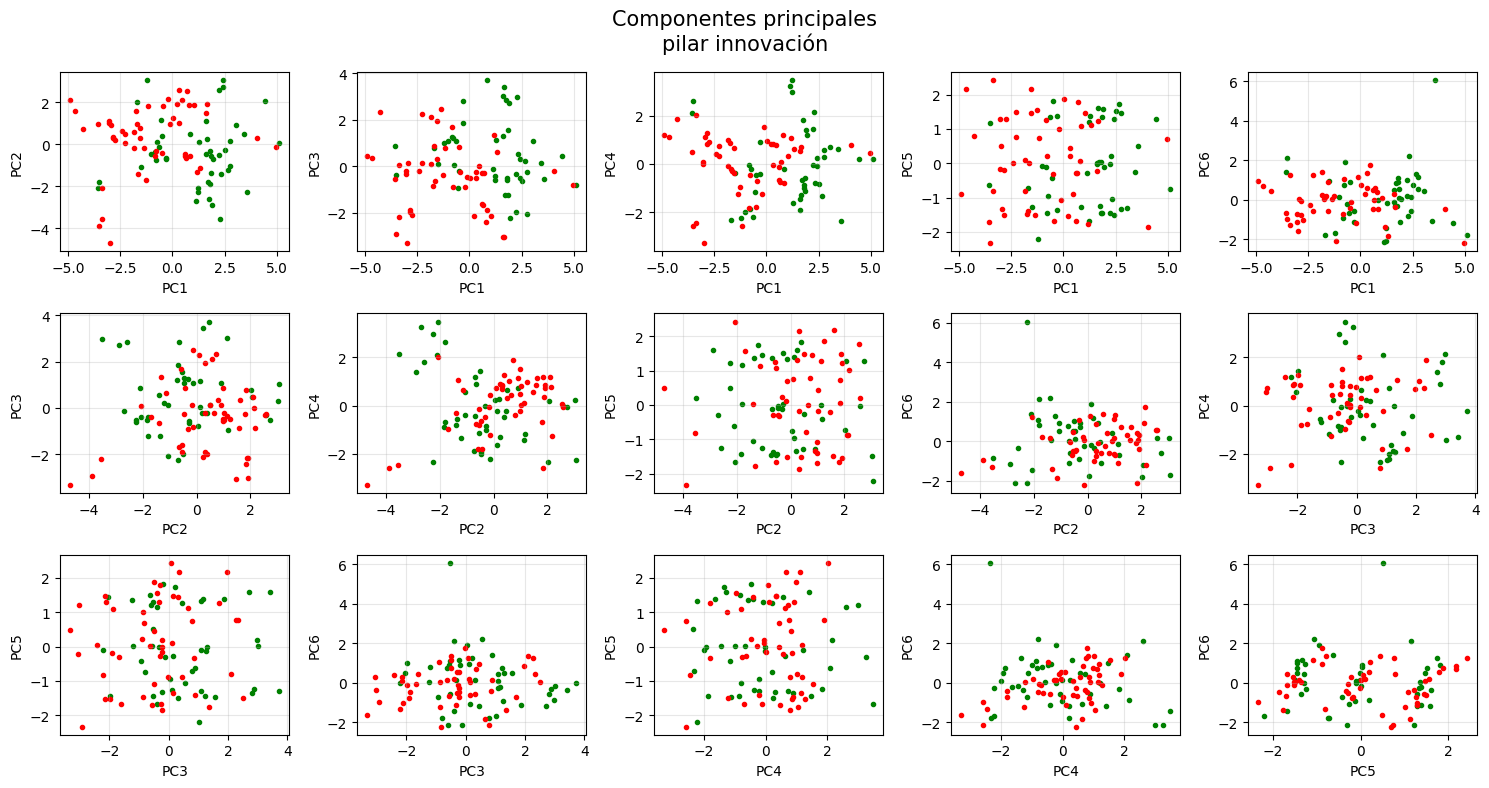

In [11]:
fig, ax = plt.subplots(3, 5, figsize = (15, 8))
ax = ax.flatten()

inds = list(combinations([i for i in range(1, 7)], r = 2))

median_y = np.mean(y)
for k, (i, j) in enumerate(inds):
    ax[k].scatter(Y[:, i-1][y >= median_y], Y[:, j-1][y >= median_y], 
                  marker = '.', color = 'green')
    ax[k].scatter(Y[:, i-1][y < median_y], Y[:, j-1][y < median_y], 
                  marker = '.', color = 'red')
    ax[k].set_xlabel(f'PC{i}'); ax[k].set_ylabel(f'PC{j}')
    ax[k].grid(alpha = 0.3)

plt.suptitle('Componentes principales\npilar innovación', fontsize = 15)
plt.tight_layout()
plt.show()

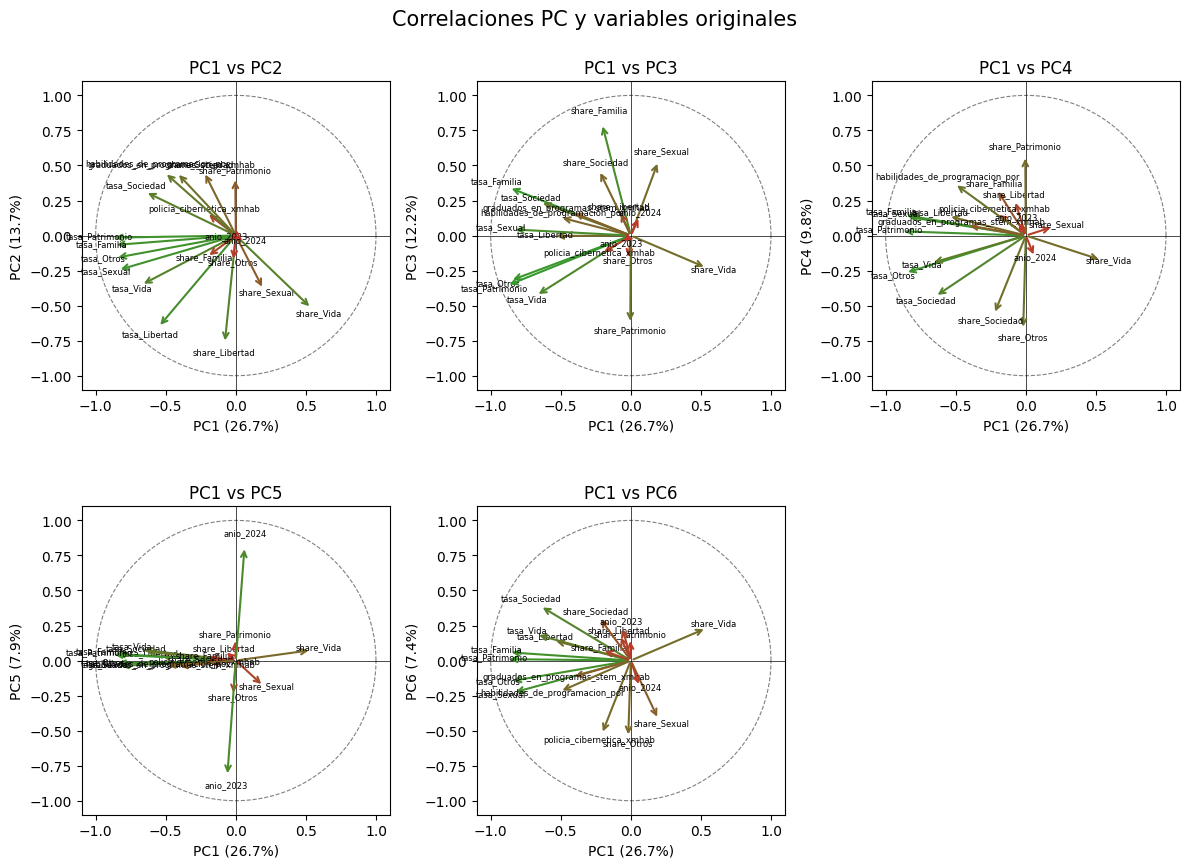

In [12]:
S = np.cov(X_scaled, rowvar = False)
evals, Gamma = np.linalg.eig(S)
Lambda = np.diag(evals)

cov_XY = Gamma @ Lambda
Dx_nsq, Dy_nsq = np.diag(np.diag(S)**(-0.5)), np.diag(evals**(-0.5))

corr_XY = Dx_nsq @ cov_XY @ Dy_nsq

corr_XY

n_pc = 6
pares = [(0,1), (0,2), (0,3), (0,4), (0,5)]

fig, axes = plt.subplots(2, 3, figsize=(12, 9))
axes = axes.flatten()
theta = np.linspace(0, 2 * np.pi, 300)

feats = [c for c in features if c != 'pilar_innovacion' and c != 'estado']
norms = []

for ax, (i, j) in zip(axes, pares):
    ax.plot(np.cos(theta), np.sin(theta), color='grey', linewidth=0.8, linestyle='--')
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)

    norms_per_feat = {}
    for k, name in enumerate(feats):
        x_, y_ = corr_XY[k, i].real, corr_XY[k, j].real
        t = (np.sqrt(x_**2 + y_**2))           
        ax.annotate('', xy=(x_, y_), xytext=(0, 0),
                    arrowprops=dict(arrowstyle='->', color=blend(t), lw=1.5))
        ax.text(x_ * 1.1, y_ * 1.1, name, fontsize=6, ha='center')
        norms_per_feat[name] = t

    norms.append(norms_per_feat)

    var_i = evals[i].real / evals.real.sum() * 100
    var_j = evals[j].real / evals.real.sum() * 100
    ax.set_xlabel(f'PC{i+1} ({var_i:.1f}%)')
    ax.set_ylabel(f'PC{j+1} ({var_j:.1f}%)')
    ax.set_aspect('equal')
    ax.set_title(f'PC{i+1} vs PC{j+1}')

axes[-1].set_axis_off()

plt.suptitle('Correlaciones PC y variables originales', fontsize = 15)
plt.tight_layout()
plt.show()

In [13]:
df_norms = pd.DataFrame(norms)
df_norms

,tasa_Familia,tasa_Libertad,tasa_Otros,tasa_Patrimonio,tasa_Sexual,tasa_Sociedad,tasa_Vida,share_Familia,share_Libertad,share_Otros,share_Patrimonio,share_Sexual,share_Sociedad,share_Vida,policia_cibernetica_xmhab,graduados_en_programas_stem_xmhab,habilidades_de_programacion_por,anio_2023,anio_2024
0,0.871863,0.855401,0.874229,0.884964,0.876496,0.717654,0.761247,0.255604,0.772617,0.186087,0.413802,0.430108,0.506598,0.747795,0.262983,0.613459,0.676979,0.062427,0.075313
1,0.934331,0.552232,0.917692,0.954225,0.842152,0.688856,0.799065,0.824127,0.191732,0.173304,0.628882,0.566523,0.517425,0.586094,0.243327,0.451445,0.523240,0.085739,0.150194
2,0.881632,0.569300,0.899994,0.885353,0.851455,0.778633,0.702636,0.387663,0.264811,0.670940,0.569804,0.206233,0.605228,0.566845,0.261992,0.426187,0.626960,0.121294,0.165455
3,0.870520,0.553230,0.859842,0.885877,0.841902,0.649397,0.679038,0.207059,0.105592,0.249290,0.157835,0.267190,0.226472,0.544280,0.208293,0.421967,0.508135,0.826540,0.816184
4,0.871199,0.570641,0.872195,0.884891,0.871679,0.754258,0.699750,0.218958,0.199848,0.547263,0.158851,0.462753,0.383050,0.586652,0.564669,0.436260,0.552871,0.249402,0.196460


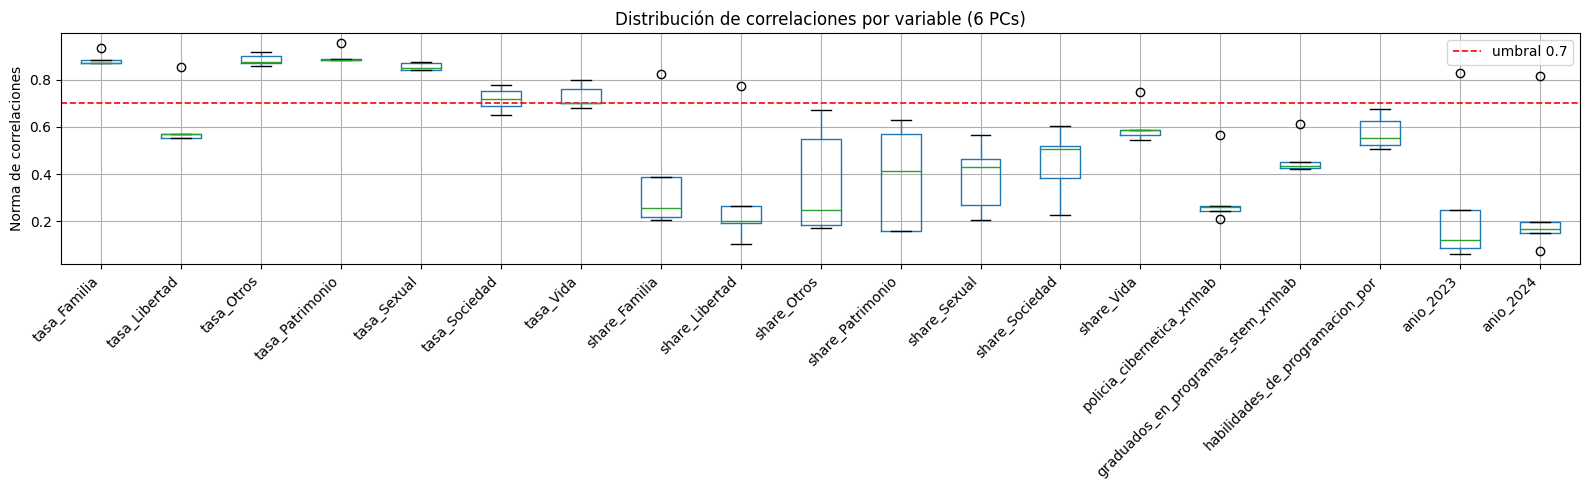

In [14]:
fig, ax = plt.subplots(figsize=(16, 5))
df_norms.boxplot(ax = ax, rot = 60)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.axhline(0.7, color='red', linestyle='--', linewidth=1.2, label='umbral 0.7')
ax.set_ylabel('Norma de correlaciones')
ax.set_title('Distribución de correlaciones por variable (6 PCs)')
ax.legend()
plt.tight_layout()
plt.show()

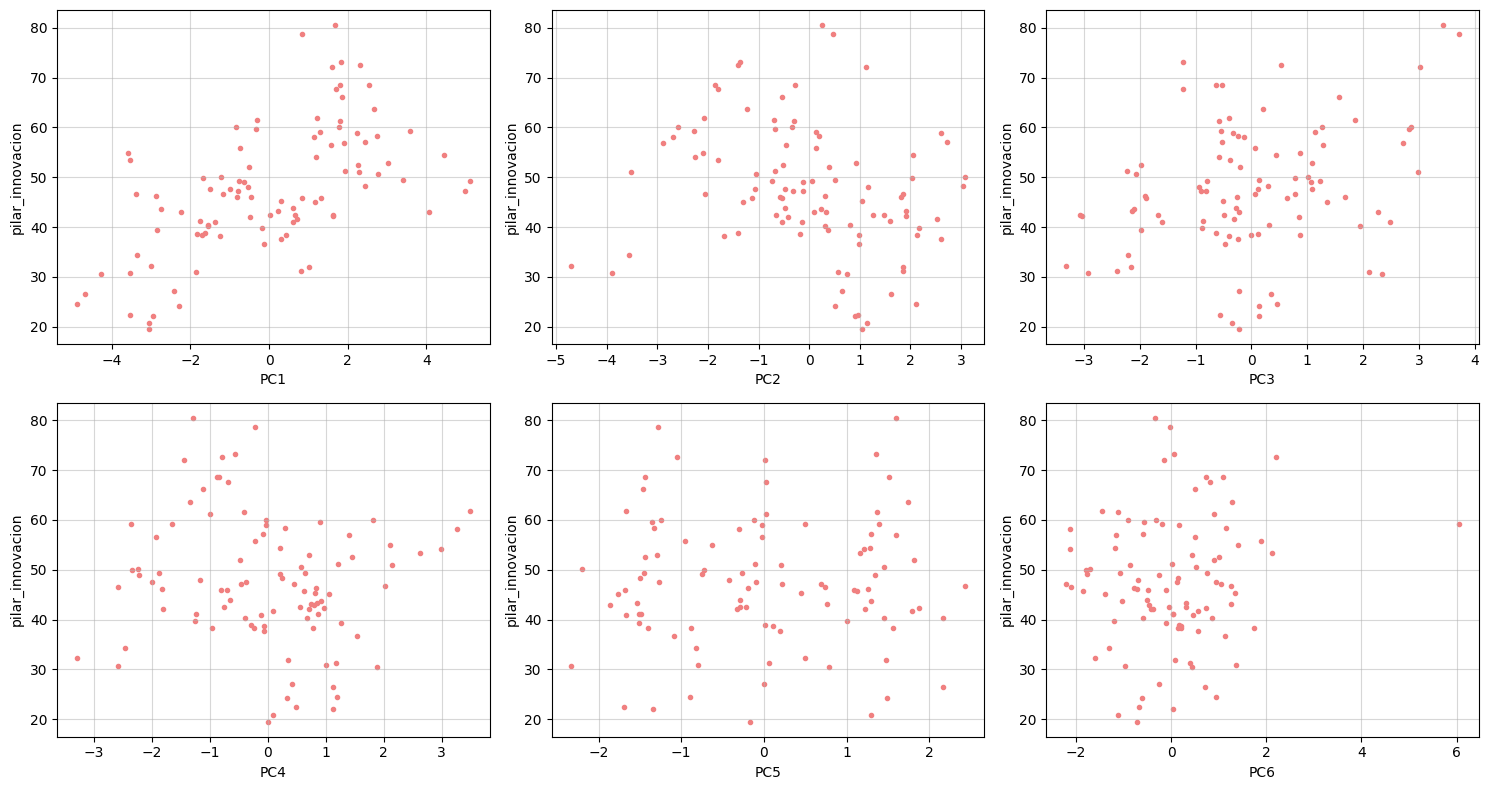

In [15]:
fig, ax = plt.subplots(2, n_components//2, figsize = (15, 8))
ax = ax.flatten()

Y_80 = Y[:, :n_components]
for i in range(n_components):
    ax[i].scatter(Y_80[:, i], y, marker = '.', color = 'lightcoral')
    ax[i].set_xlabel(f'PC{i+1}')
    ax[i].set_ylabel('pilar_innovacion')
    ax[i].grid(alpha = 0.5)

plt.tight_layout()
plt.show()

In [18]:
cols_model = [c for c in df_norms if (df_norms[c] >= 0.7).sum() > 0]
df_model = df_main[cols_model]
X_model = df_model.values

X_train, X_test, y_train, y_test = train_test_split(
    X_model, y,
    test_size = 0.2,      
    random_state = 42     
)

# --------------- Random Forest ---------------
rf = RandomForestRegressor(n_estimators = 200, random_state = 42, n_jobs = -1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [19]:
cv_r2 = cross_val_score(rf, X_model, y, cv=5, scoring='r2')

print("=== Random Forest — Regresión (pilar_innovacion) ===")
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.3f}")
print(f"\nCV R² (5-fold): {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")

=== Random Forest — Regresión (pilar_innovacion) ===
MAE:  5.385
RMSE: 6.968

CV R² (5-fold): 0.7510 ± 0.0704


        feature  importance      std
  tasa_Sociedad    0.788328 0.090760
tasa_Patrimonio    0.149371 0.019738
  share_Familia    0.082774 0.012832
     share_Vida    0.064847 0.013778
  tasa_Libertad    0.062234 0.010562
   tasa_Familia    0.061811 0.014761
    tasa_Sexual    0.032204 0.005475
      tasa_Vida    0.027588 0.004142
     tasa_Otros    0.016290 0.003559
 share_Libertad    0.012738 0.002554
      anio_2024    0.000640 0.000452
      anio_2023   -0.000535 0.000968


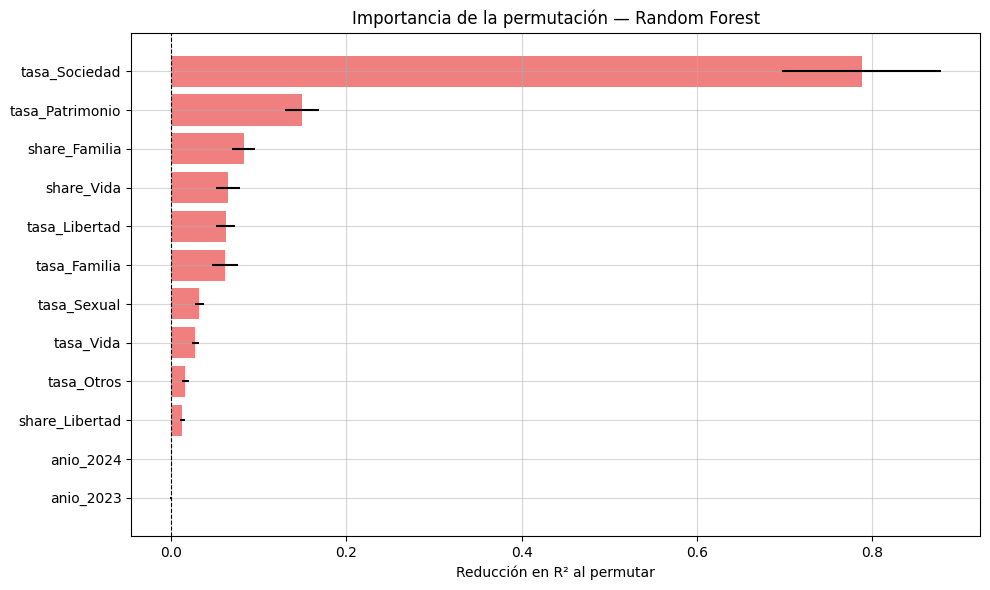

In [20]:
perm = permutation_importance(
    rf, X_model, y,
    n_repeats=30,      
    random_state=42,
    scoring='r2'
)

perm_df = pd.DataFrame({
    'feature': cols_model,
    'importance': perm.importances_mean,
    'std':        perm.importances_std
}).sort_values('importance', ascending=False)

print(perm_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(perm_df['feature'], perm_df['importance'], xerr=perm_df['std'], align='center', color = 'lightcoral')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Reducción en R² al permutar')
ax.set_title('Importancia de la permutación — Random Forest')
ax.invert_yaxis()
ax.grid(alpha = 0.5)

plt.tight_layout()
plt.show()

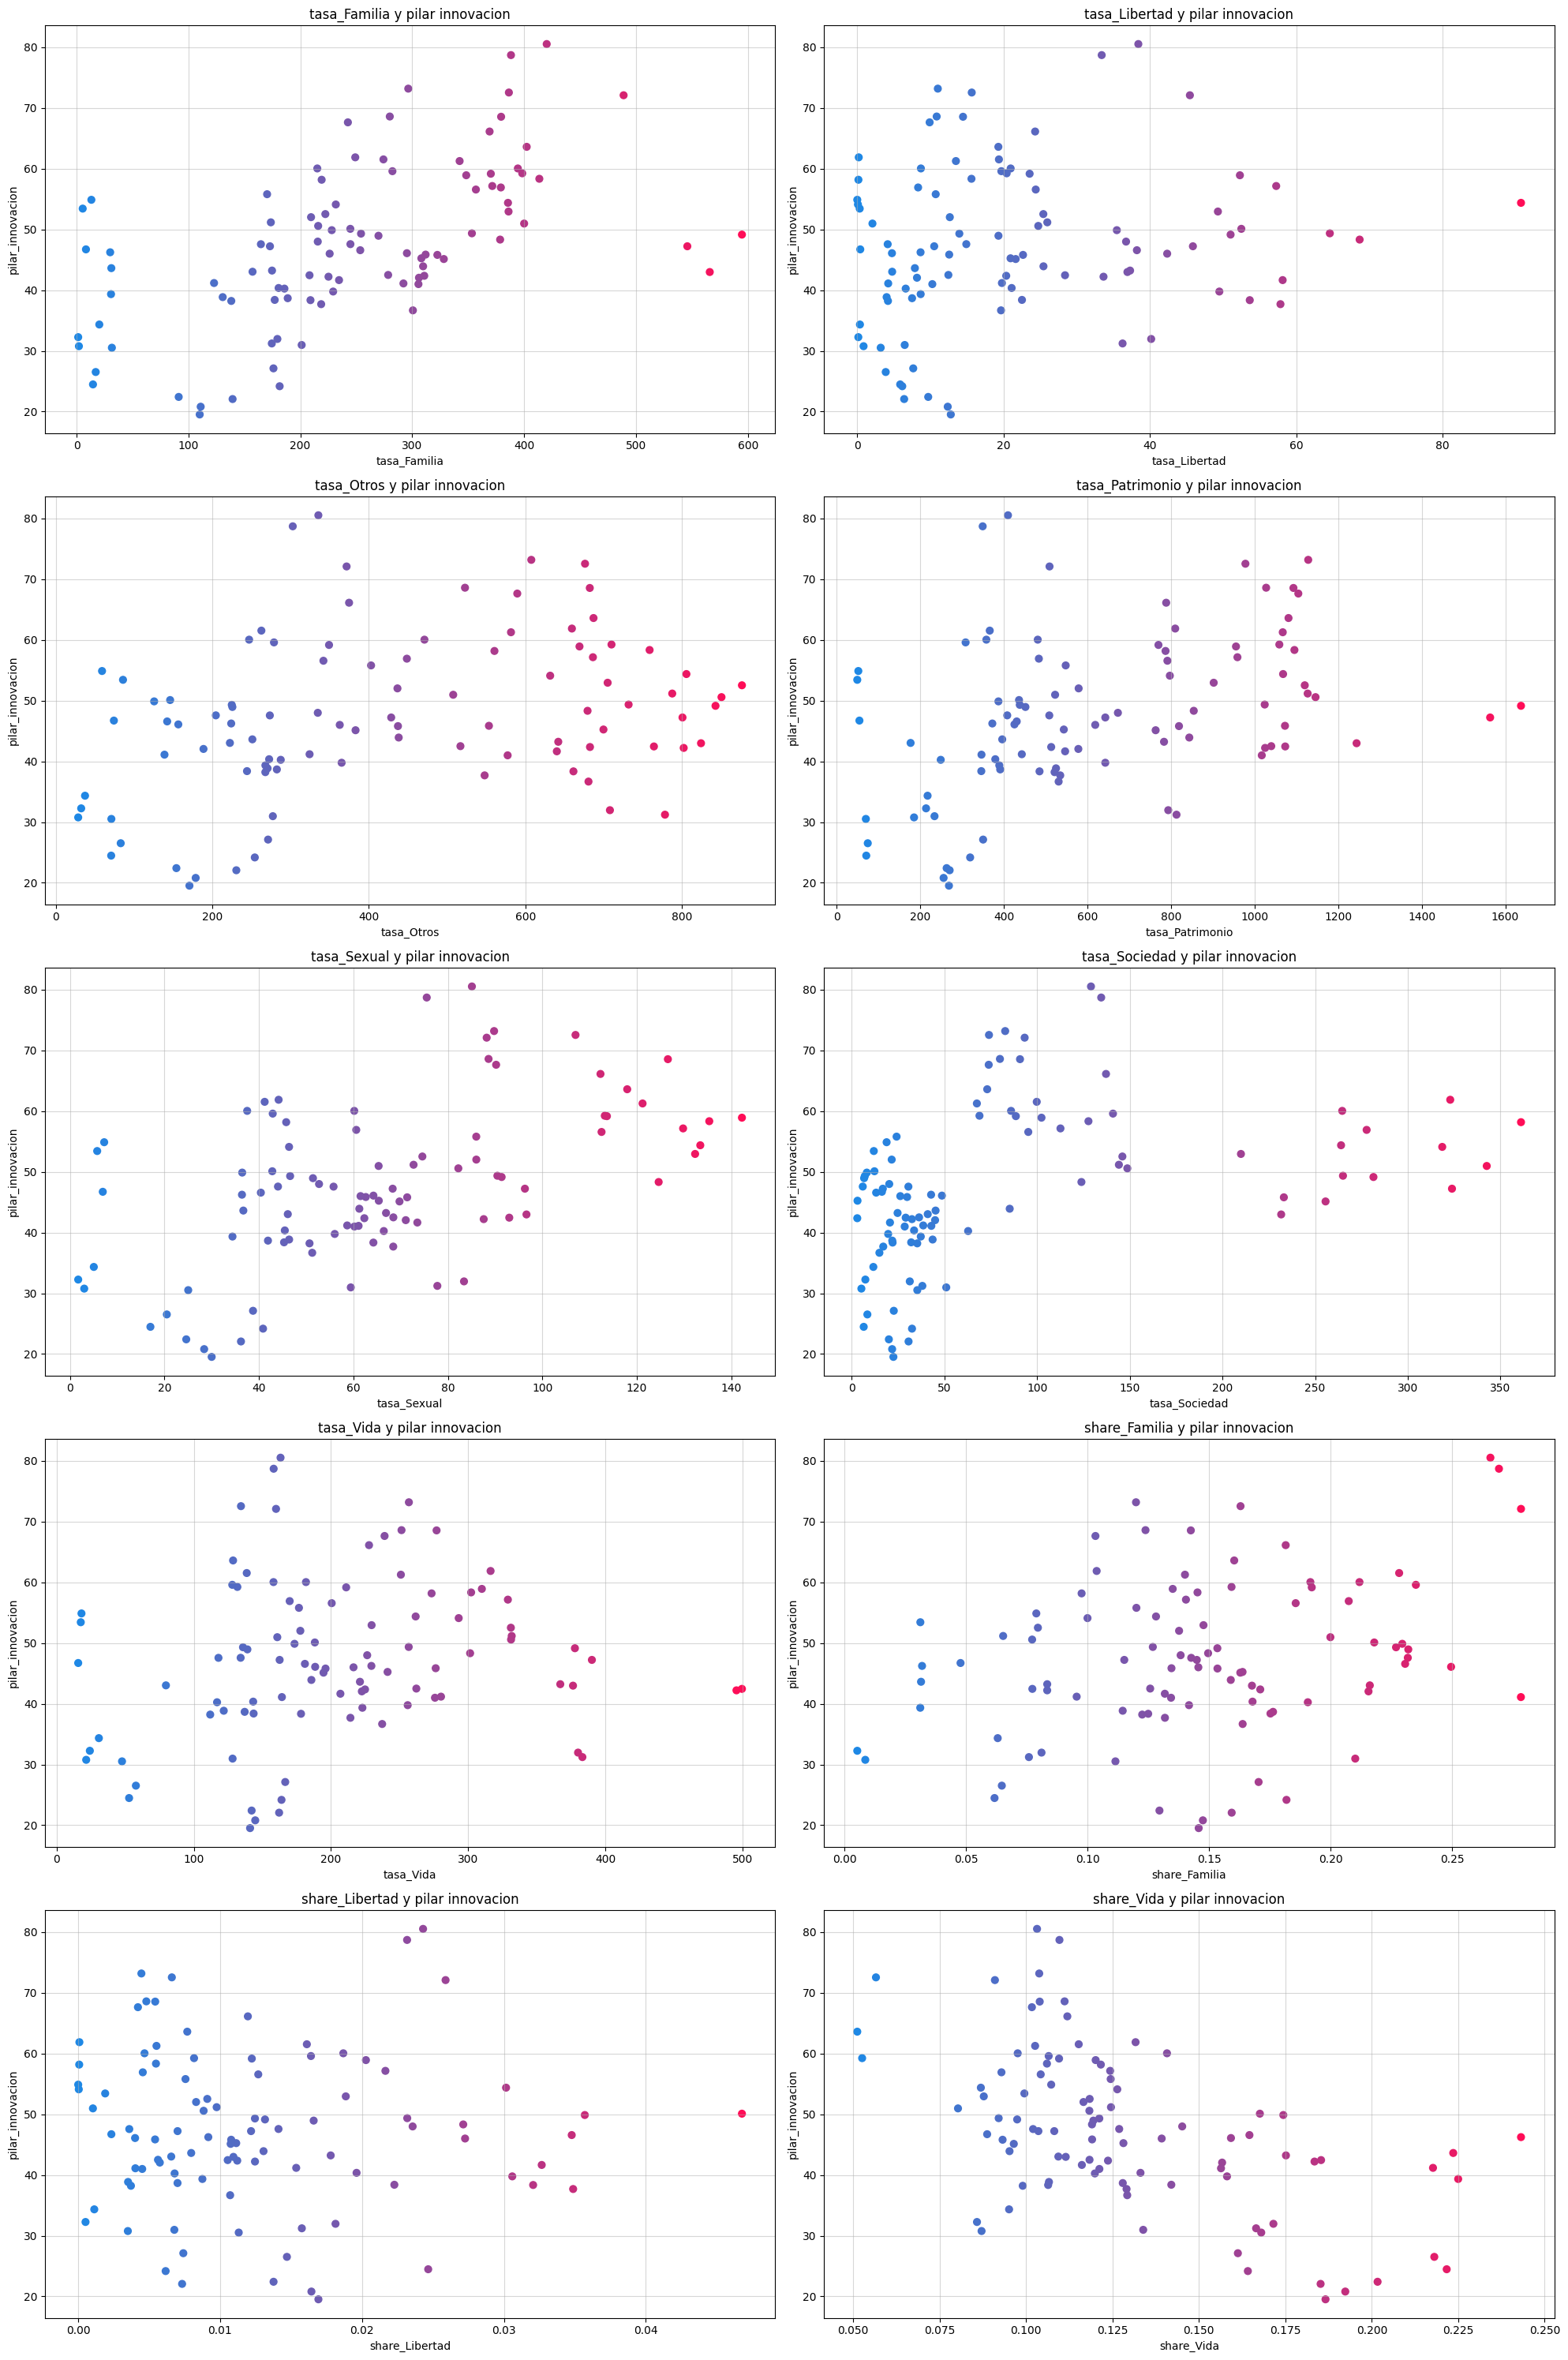

In [21]:
fig, ax = plt.subplots(5, 2, figsize = (20, 30))
ax = ax.flatten()

for i, col in enumerate(cols_model[:-2]):
    blue, pink = np.array([0.118, 0.533, 0.898]), np.array([1.000, 0.051, 0.341])
    min_ts= df_model[col].min()
    max_ts = df_model[col].max()
    normalized_ts = (df_model[col] - min_ts) / (max_ts - min_ts)

    blend = lambda t, c1, c2: (1 - t) * c1 + t * c2
    colors_fade = [blend(t, blue, pink) for t in normalized_ts]

    ax[i].scatter(df_model[col], y, color = colors_fade, s = 40)
    # for _, row in df2.iterrows():
    #     ax[i].text(
    #         row[col], row['pilar_innovacion'],
    #         s = f"{row['estado']}\n({row['anio']})", ha = 'center', va = 'bottom', fontsize = 10
    #     )

    ax[i].grid(alpha = 0.5)
    ax[i].set_xlabel(col); ax[i].set_ylabel('pilar_innovacion')
    ax[i].set_title(f'{col} y pilar innovacion')

plt.tight_layout()
plt.show()

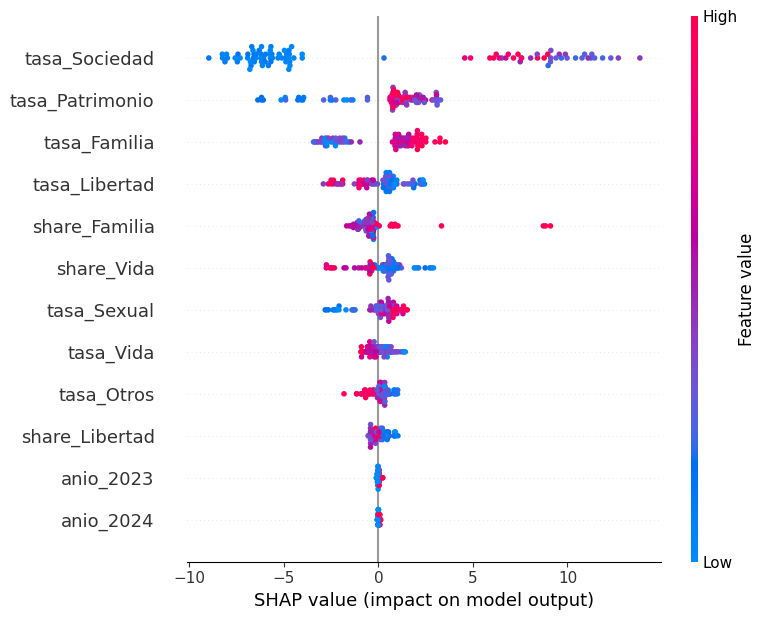

In [22]:
import shap

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_model)

shap.summary_plot(shap_values, X_model, feature_names = cols_model)

In [90]:
from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators':     [100, 200, 500],
    'max_depth':        [3, 5, 10, None],
    'min_samples_leaf': [1, 2, 5],
    'max_features':     ['sqrt', 'log2', 0.5]
}

search = RandomizedSearchCV(rf, params, cv=5, scoring='r2', n_iter=30, random_state=42)
search.fit(X_model, y)
print(search.best_params_)

{'n_estimators': 200, 'min_samples_leaf': 1, 'max_features': 0.5, 'max_depth': None}


## 4. DataFrame 3 — Snapshot 2022: Perfil Integral por Estado

**n ≈ 32 obs** (un registro por estado, corte transversal 2022)

| Columna | Descripción |
|---------|-------------|
| `estado` | Identificador |
| `tasa_x100k` | Tasa total de incidencia por 100,000 habitantes |
| `tasa_Vida`, `tasa_Patrimonio`, … | Tasas per cápita por categoría |
| `variacion_pib` | Crecimiento % del PIB estatal en 2022 |
| `idde_score` | Índice de Desarrollo Digital Estatal 2022 |
| `pilar_infraestructura` | Pilar de conectividad y acceso |
| `pilar_sociedad` | Pilar de digitalización de personas y sociedad |
| `pilar_innovacion` | Pilar de innovación y adopción empresarial |
| `grupo_label` | Grupo de digitalización ← **target clasificación** |

In [91]:
tasa_cols = [c for c in df1.columns if c.startswith('tasa_') and c != 'tasa_x100k']

df3_crime = df1[df1['anio'] == 2022][['estado','tasa_x100k'] + tasa_cols + ['variacion_pib']].copy()
df3_idde  = df2[df2['anio'] == 2022][['estado','idde_score','pilar_infraestructura',
                                       'pilar_sociedad','pilar_innovacion','grupo_label']].copy()
df3 = df3_crime.merge(df3_idde, on='estado', how='inner')

print(f'DF3 shape: {df3.shape}')
df3.head()

DF3 shape: (32, 15)


,estado,tasa_x100k,tasa_Familia,tasa_Libertad,tasa_Otros,tasa_Patrimonio,tasa_Sexual,tasa_Sociedad,tasa_Vida,variacion_pib,idde_score,pilar_infraestructura,pilar_sociedad,pilar_innovacion,grupo_label
0,Aguascalientes,2662.849355,173.620201,25.975735,787.616600,1126.983527,72.745518,144.145143,331.762631,-1.947906,167.9890,65.31,51.51,51.16,Avanzado
1,Baja California,2786.113314,353.313771,64.594339,731.866053,1024.165596,90.493013,265.029762,256.650779,2.608086,181.0170,71.21,60.46,49.35,Avanzado
2,Baja California Sur,2444.446301,342.337032,13.483473,581.579189,1067.342193,121.231936,67.536689,250.935789,7.484190,184.8080,65.53,58.03,61.25,Líder
3,Campeche,2695.863408,208.186194,28.398624,764.229136,1073.235722,93.008132,29.137621,499.667979,-5.578943,132.5400,43.57,46.52,42.45,Emprendedor
4,Chiapas,283.086059,31.542460,3.202011,70.921885,69.418179,25.032294,35.399025,47.570205,5.317995,66.4035,16.49,19.40,30.52,Básico
